<a href="https://colab.research.google.com/github/JavierCarrillo12/Computacion-visual-jtorresle-jugomezra-dagarzonmo-jacarrillo/blob/main/Talleres/2025-07-04_taller_controlnet_condiciones_visuales_stablediffusion/colab/2025_07_04_taller_controlnet_condiciones_visuales_stablediffusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install diffusers transformers accelerate safetensors controlnet_aux --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.4/290.4 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 62.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 53.1 MB/s eta 0:00:00


## Condición de canny

In [15]:
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel
from controlnet_aux import CannyDetector
import torch

controlnet = ControlNetModel.from_pretrained("lllyasviel/sd-controlnet-canny", torch_dtype=torch.float16)
pipe = StableDiffusionControlNetPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    controlnet=controlnet,
    torch_dtype=torch.float16
).to("cuda")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

In [16]:
from PIL import Image
import numpy as np

image = Image.open("IMG-20250313-WA0056.jpg").resize((512, 512))
detector = CannyDetector()
condition_image = detector(image)

In [17]:
import torch
import torchvision.transforms as T

transform = T.ToTensor()
condition_image_tensor = transform(condition_image).to(torch.float16).unsqueeze(0)

result = pipe("A cyberpunk city skyline at night", image=condition_image_tensor, num_inference_steps=30).images[0]
result.save("resultado_controlnet.png")

  0%|          | 0/30 [00:00<?, ?it/s]

### Limpieza de memoria para cargar el otro modelo

In [18]:
try:
  del pipe
except:
  pass
try:
  del controlnet
except:
  pass

In [19]:
import torch
torch.cuda.empty_cache()

### Solo texto

In [20]:
from diffusers import StableDiffusionPipeline
import torch

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",       # O usa otro como SDXL
    torch_dtype=torch.float16
).to("cuda")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

In [21]:
prompt = "A cyberpunk city skyline at night"
generator = torch.Generator("cuda").manual_seed(1234)

image = pipe(
    prompt=prompt,
    num_inference_steps=40,
    guidance_scale=7.5,
    generator=generator
).images[0]

image.save("output_normal_cyberpunk.png")

  0%|          | 0/40 [00:00<?, ?it/s]

### Resultado con Condición de Canny

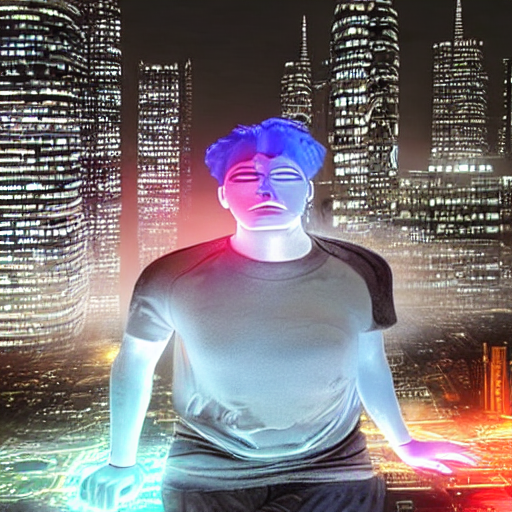

In [22]:
from IPython.display import display, Image

display(Image("resultado_controlnet.png"))

### Resultado normal prompt

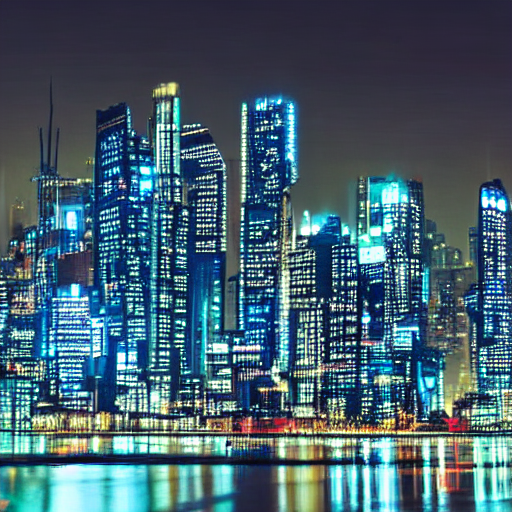

In [23]:
display(Image("output_normal_cyberpunk.png"))

## Limpieza de memoria para cargar el otro modelo

In [34]:
try:
  del pipe
except:
  pass
try:
  del controlnet
except:
  pass

In [35]:
import torch
torch.cuda.empty_cache()

## Condición de profundidad

In [36]:
from PIL import Image
from transformers import DPTFeatureExtractor, DPTForDepthEstimation
import numpy as np
import cv2
import torch

# 1. Estimar profundidad con MiDaS
feature_extractor = DPTFeatureExtractor.from_pretrained("Intel/dpt-large")
depth_model      = DPTForDepthEstimation.from_pretrained("Intel/dpt-large").to("cuda")

img = Image.open("IMG-20250313-WA0056.jpg").convert("RGB").resize((512, 512))
inputs = feature_extractor(images=img, return_tensors="pt").to("cuda")
pred = depth_model(**inputs).predicted_depth

# Normalizar y convertir a PIL
depth = torch.nn.functional.interpolate(
    pred.unsqueeze(1), size=img.size[::-1], mode="bilinear"
)[0,0]
arr = depth.detach().cpu().numpy()
arr = 255 * (arr - arr.min())/(arr.max() - arr.min())
depth_image = Image.fromarray(arr.astype(np.uint8))

preprocessor_config.json:   0%|          | 0.00/285 [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/transformers/models/dpt/feature_extraction_dpt.py:30: FutureWarning: The class DPTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use DPTImageProcessor instead.
  warnings.warn(


config.json:   0%|          | 0.00/942 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.37G [00:00<?, ?B/s]

Some weights of DPTForDepthEstimation were not initialized from the model checkpoint at Intel/dpt-large and are newly initialized: ['neck.fusion_stage.layers.0.residual_layer1.convolution1.bias', 'neck.fusion_stage.layers.0.residual_layer1.convolution1.weight', 'neck.fusion_stage.layers.0.residual_layer1.convolution2.bias', 'neck.fusion_stage.layers.0.residual_layer1.convolution2.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [37]:
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel
# 2. Cargar ControlNet Depth
controlnet = ControlNetModel.from_pretrained(
    "lllyasviel/sd-controlnet-depth", torch_dtype=torch.float16
).to("cuda")

pipe = StableDiffusionControlNetPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    controlnet=controlnet,
    torch_dtype=torch.float16
).to("cuda")

config.json:   0%|          | 0.00/920 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/1.45G [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

In [38]:
import torch
import torchvision.transforms as T
import os

os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

result = pipe("Una persona posando en New York", image=depth_image, num_inference_steps=30).images[0]
result.save("resultado_controlnet_depth.png")

  0%|          | 0/30 [00:00<?, ?it/s]

### Limpieza de memoria para cargar el otro modelo

In [40]:
try:
  del pipe
except:
  pass
try:
  del controlnet
except:
  pass

In [41]:
import torch
torch.cuda.empty_cache()

### Solo texto

In [42]:
from diffusers import StableDiffusionPipeline
import torch

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",       # O usa otro como SDXL
    torch_dtype=torch.float16
).to("cuda")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

In [43]:
prompt = "Una persona posando en New York"
generator = torch.Generator("cuda").manual_seed(1234)

image = pipe(
    prompt=prompt,
    num_inference_steps=40,
    guidance_scale=7.5,
    generator=generator
).images[0]

image.save("output_normal_New_York.png")

  0%|          | 0/40 [00:00<?, ?it/s]

### Resultado

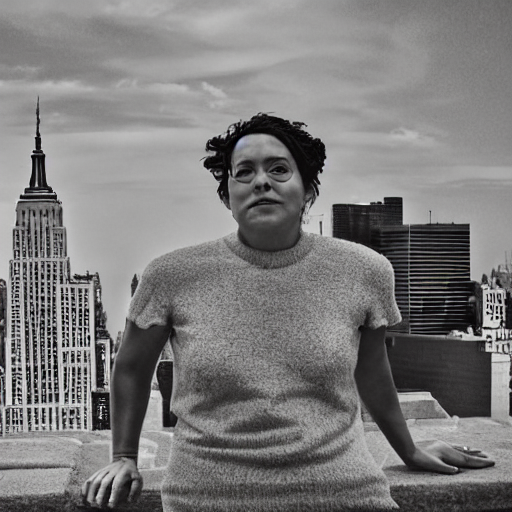

In [39]:
from IPython.display import display, Image

display(Image("resultado_controlnet_depth.png"))

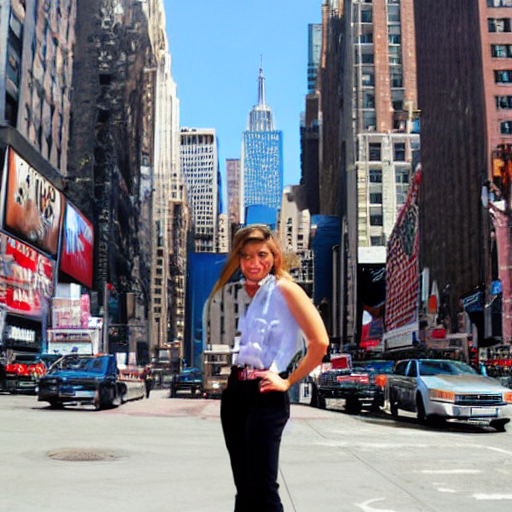

In [44]:
display(Image("output_normal_New_York.png"))

## Limpieza de memoria para cargar el otro modelo

In [31]:
try:
  del pipe
except:
  pass
try:
  del controlnet
except:
  pass

In [ ]:
import torch
torch.cuda.empty_cache()

## Condición de pose

In [2]:
from PIL import Image
from diffusers import ControlNetModel, StableDiffusionControlNetPipeline
import torch

# 1. Carga tu imagen ya “pose-estimada” (ej. exportada desde OpenPose)
pose_image = Image.open("standing_15.png")  # blanco sobre negro con líneas


In [3]:
# 2. Cargar ControlNet OpenPose
controlnet = ControlNetModel.from_pretrained(
    "lllyasviel/sd-controlnet-openpose", torch_dtype=torch.float16
).to("cuda")

pipe = StableDiffusionControlNetPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    controlnet=controlnet,
    torch_dtype=torch.float16
).to("cuda")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/920 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/1.45G [00:00<?, ?B/s]

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

...

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/806 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

In [5]:
# 3. Generar
out = pipe(
    prompt="Un bailarín en movimiento, estilo pintura digital",
    image=pose_image,
    num_inference_steps=30,
    guidance_scale=7.5
)
out.images[0].save("output_pose.png")

  0%|          | 0/30 [00:00<?, ?it/s]

### Limpieza de memoria para cargar el otro modelo

In [30]:
try:
  del pipe
except:
  pass
try:
  del controlnet
except:
  pass

In [ ]:
import torch
torch.cuda.empty_cache()

### Solo texto

In [25]:
from diffusers import StableDiffusionPipeline
import torch

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",       # O usa otro como SDXL
    torch_dtype=torch.float16
).to("cuda")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

In [26]:
prompt = "Un bailarín en movimiento, estilo pintura digital"
generator = torch.Generator("cuda").manual_seed(1234)

image = pipe(
    prompt=prompt,
    num_inference_steps=40,
    guidance_scale=7.5,
    generator=generator
).images[0]

image.save("output_normal_bailarin.png")

  0%|          | 0/40 [00:00<?, ?it/s]

### Resultado con Condición de Pose

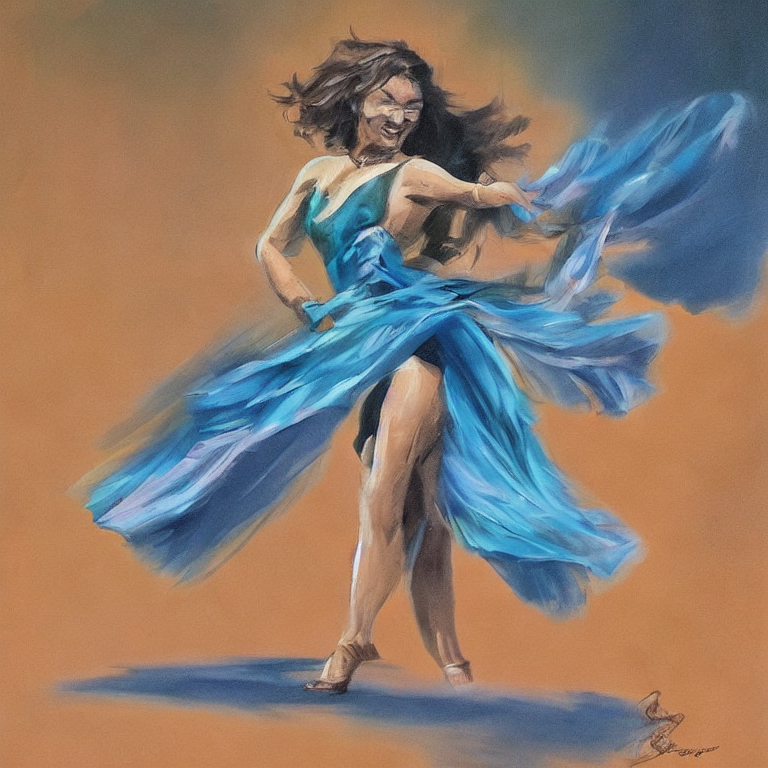

In [6]:
from IPython.display import display, Image

display(Image("output_pose.png"))

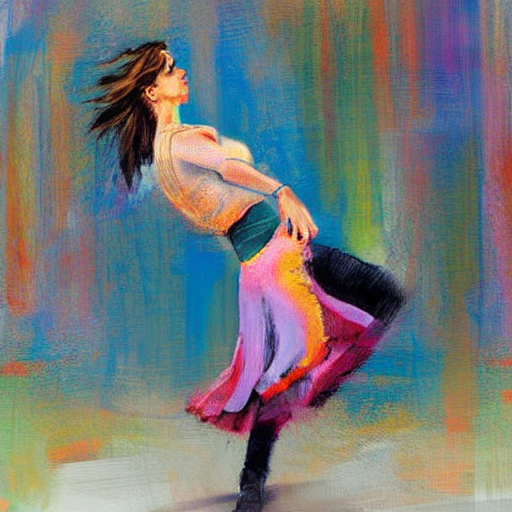

In [28]:
display(Image("output_normal_bailarin.png"))